In [59]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib import colormaps
import pandas as pd

In [60]:
plt.style.use('ggplot')
# plt.rcParams['text.color'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

# Simulation

In this section, we will explore statistical simulation techniques based on historical data. The application will be to use is to simulate wind speed data based on historical data.

## Data Visualization

The data is from the Kelmarsh wind farm in the UK. The data is from the year 2016 and is sampled at 10 minute intervals, [https://zenodo.org/records/5841834#.YgpBQ_so-V7](https://zenodo.org/records/5841834#.YgpBQ_so-V7)

In [61]:
df = pd.read_parquet("wind_speed.parquet")

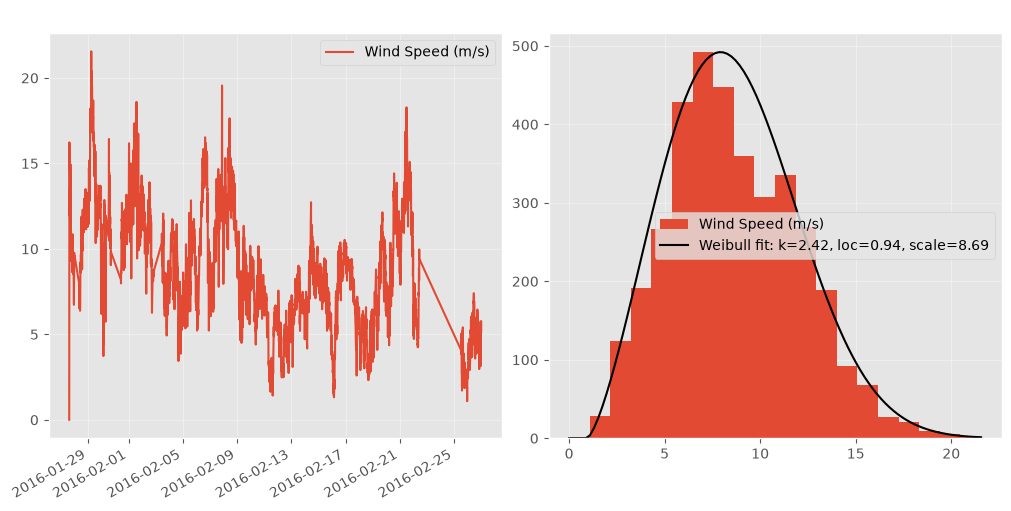

In [62]:
_, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
bins = 20
df.plot(ax=axes[0])
df.hist(ax=axes[1], bins=bins, legend=True)

kappa, loc, scale = stats.weibull_min.fit(df.iloc[:,0].values)
x = np.linspace(df.values.min(), df.values.max(), 100)
pdf = stats.weibull_min.pdf(x, c=kappa, loc=loc, scale=scale)

pdf *= pd.cut(df.iloc[:,0], bins=bins).value_counts().max()/np.max(pdf)
axes[1].plot(x, pdf, color='black', label=f'Weibull fit: k={kappa:.2f}, loc={loc:.2f}, scale={scale:.2f}')
axes[1].legend();

## Probability integral transform

This is an important result that is used in statistical simulation. It states that a random variable $X$ that has a continuous distribution and a cumulative distribution function (CDF) $F_X(x)$, then the random variable $Y = F_X(X)$ is uniformly distributed on the interval [0, 1].

Moreover, if $U$ is a random variable that is uniformly distributed on the interval [0, 1], then the random variable $X = F_X^{-1}(U)$ has the same distribution as $X$.

This is an useful result when we want to simulate random variables that follow a given distribution. We will do this by first sampling a normal distribution, and then transforming it to a uniform distribution using the CDF before transforming it to the Weibull distribution using the inverse CDF.

In [63]:
N = 1_000
x_normal = np.random.normal(loc=2.0, scale=3.2, size=N)
x_uniform = stats.norm.cdf(x_normal, loc=2.0, scale=3.2)
x_weibull = stats.weibull_min.ppf(x_uniform, c =kappa, loc=loc, scale=scale)

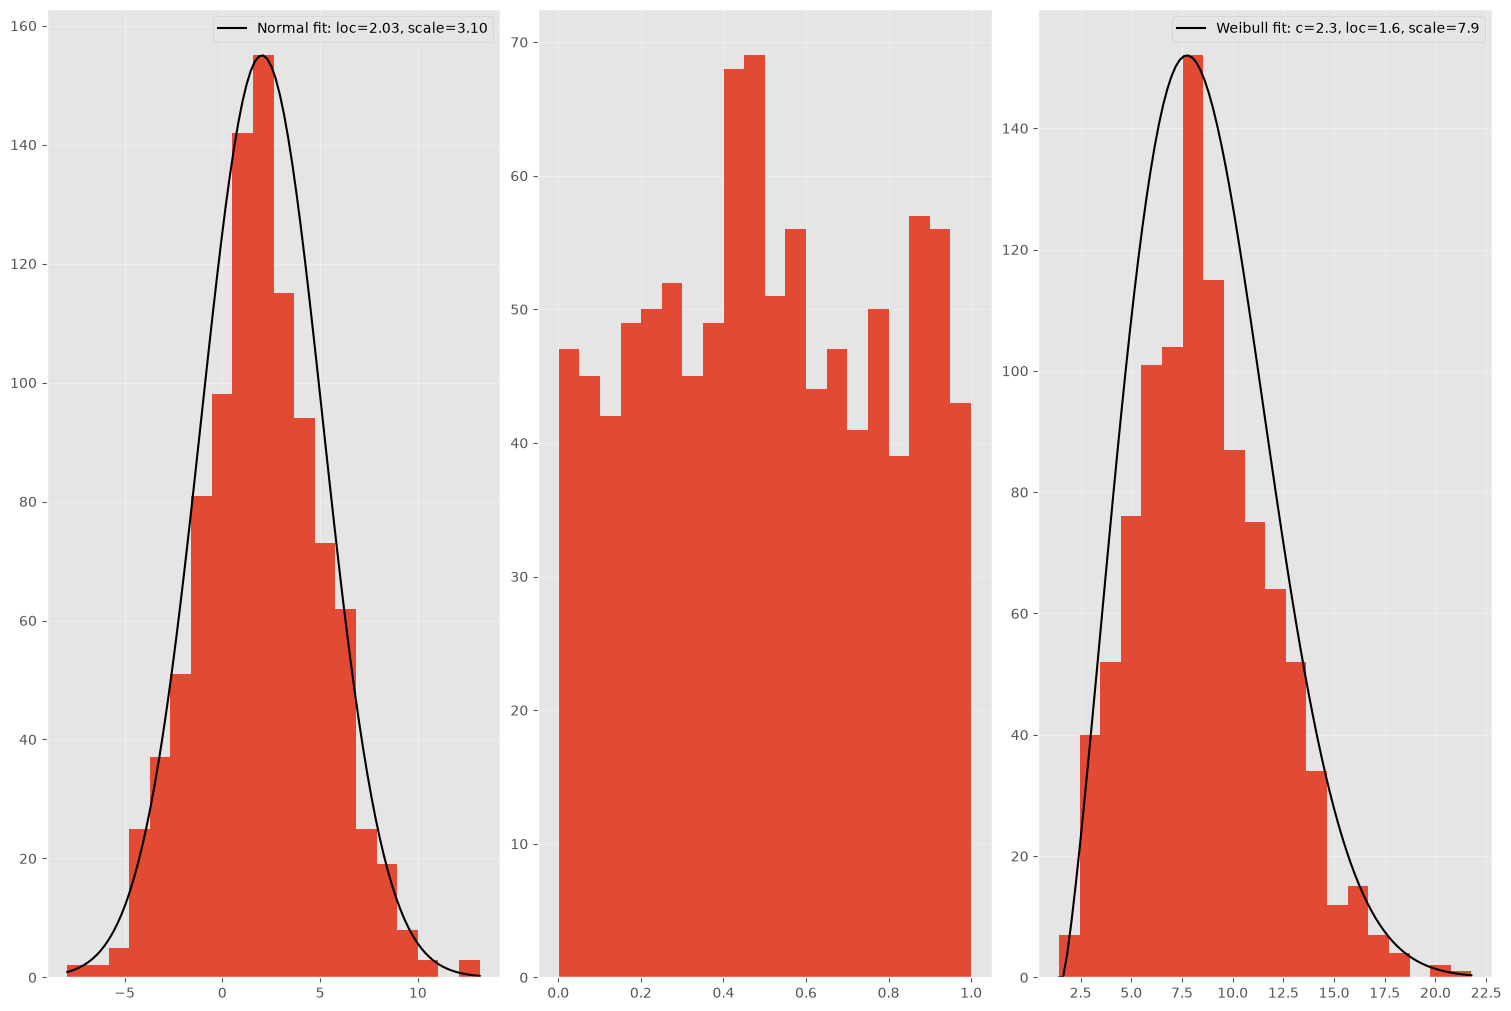

In [66]:
fix, axes = plt.subplots(ncols=3, figsize=(15, 10), constrained_layout=True)

bins = 20

axes[0].hist(x_normal, bins=bins)
normal_loc, normal_scale = stats.norm.fit(x_normal)
x = np.linspace(x_normal.min(), x_normal.max(), 100)
pdf = stats.norm.pdf(x, loc=normal_loc, scale=normal_scale)
pdf *= pd.cut(x_normal, bins=bins).value_counts().max()/np.max(pdf)
axes[0].plot(x, pdf, color='black', label=f'Normal fit: loc={normal_loc:.2f}, scale={normal_scale:.2f}')
axes[0].legend()
axes[1].hist(x_uniform, bins=bins)

axes[2].hist(x_weibull, bins=bins)
weibull_c, x_weibull_loc, weibull_scale = stats.weibull_min.fit(x_weibull)
x = np.linspace(x_weibull.min(), x_weibull.max(), 100)
pdf = stats.weibull_min.pdf(x, c=weibull_c, loc=x_weibull_loc, scale=weibull_scale)
pdf *= pd.cut(x_weibull, bins=bins).value_counts().max()/np.max(pdf)
axes[2].plot(x, pdf, color='black', label=f'Weibull fit: c={weibull_c:.1f}, loc={x_weibull_loc:.1f}, scale={weibull_scale:.1f}')
axes[2].legend();

# NORmal to anything (NORTA)

This is a technique from the [paper](https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/5d499a3efc8ae4dfc125756c00391ca6/$FILE/NORTA.pdf)

Say we want to generate multiple random variables that have a given correlation structure and distributions. If the distributions we wand are **closed under convolution** then we could create new random variables by adding these together. However, this only holds through for a few continuous distributions (Normal, Poisson, Chi-Square, Gamma, Binomial). If we instead take advantage of the probability integral transform, we can generate random variables with any distribution and correlation structure. The steps are as follows:

1. Generate a multivariate normal random variable with the desired correlation structure.
2. Transform the multivariate normal random variable to a uniform random variable using the CDF.
3. Transform the uniform random variable to the desired distribution using the inverse CDF.


**Important**: Note that this also appies to correlation with itself. Meaning that we can have a single random variable, but which is a sequence (time series) in which each step is highly correlated with the previous step. This is important for simulating wind speed data, as wind speed is highly correlated with itself over time.


## Fit Distribution

Wind speed data is often modeled using the Weibull distribution. This distribution is defined by

$f(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}e^{-(x/\lambda)^k} \quad x \geq 0$

and

$f(x) = 0 \quad x < 0$


where $k$ is the shape parameter and $\lambda$ is the scale parameter. We can fit the Weibull distribution to the wind speed data using the `scipy.stats` library.

